# <b>Differential Gene Expression Analysis</b>
## Using DeSEQ2 with biological replicates

In [1]:
import custom_functions_pydeseqEnv as cf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import scanpy as sc
import seaborn as sns
import warnings
from custom_functions_pydeseqEnv import plot_volcano_df, plot_volcano_df_html, return_de
from matplotlib.pyplot import rc_context

In [2]:
# Set the seed
np.random.seed(123)

#warnings.filterwarnings("ignore")

## Loading the data

In [ ]:
adata = sc.read_h5ad("../data/adata_all_samples_preprocessed.h5ad")

In [ ]:
annotate = sc.read_h5ad('../data/adata_all_samples_annotated.h5ad')

In [5]:
### We'll normalize and log transform the data in adata here
### Deseq will take in data from the "counts" layer which is unnormalized.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [6]:
### Then we add annotations, clusters, and UMAP coordinates
adata.obs['celltype'] = annotate.obs.celltype.copy() 
adata.obs['celltype_broad'] = annotate.obs.celltype_broad.copy() 
adata.obs['leiden'] = annotate.obs.leiden.copy()
adata.obsm['X_umap'] = annotate.obsm['X_umap'].copy()

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


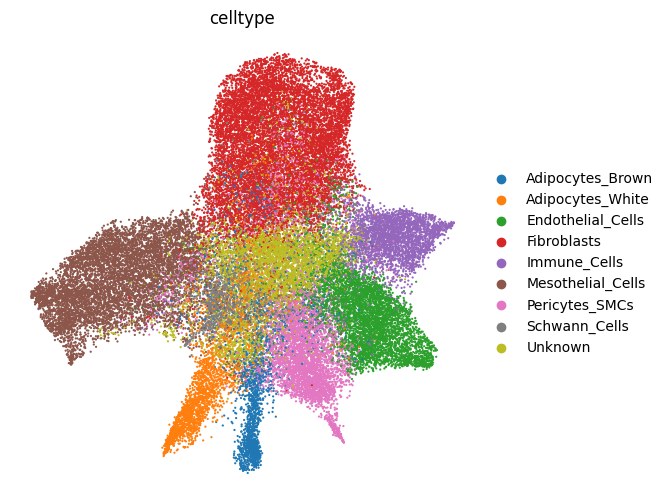

In [7]:
with rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(adata, color = ['celltype'], frameon = False, s = 10)

## Using DESeq across high-level comparisons

In [ ]:
### Create comparison groups for each tissue vs the rest of the tissues for Deseq2 analysis
target = "Kidney"
adata.obs['comparison-group-Kidney'] = adata.obs['tissue'].apply(
    lambda x: target if x == target else 'Rest'
)

target = "Mesentery"
adata.obs['comparison-group-Mesentery'] = adata.obs['tissue'].apply(
    lambda x: target if x == target else 'Rest'
)

target = "Thoracic_Aorta"
adata.obs['comparison-group-Thoracic-Aorta'] = adata.obs['tissue'].apply(
    lambda x: target if x == target else 'Rest'
)

Comparing across Rest mesothelium in whole_tissue


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.56 seconds.

Fitting dispersion trend curve...
... done in 3.80 seconds.

Fitting MAP dispersions...
... done in 1.54 seconds.

Fitting LFCs...
... done in 1.76 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



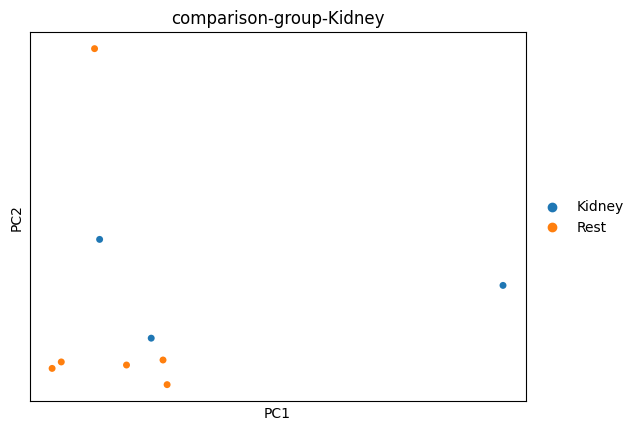

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 21.10 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.382260,0.519008,2.038160,0.254646,0.798997,NaN
3110082J24Rik,1.095163,0.278818,3.114945,0.089510,0.928677,NaN
4930455H04Rik,9.472874,0.048790,0.688005,0.070915,0.943465,NaN
4933400A11Rik,0.301683,18.716754,364.372899,0.051367,0.959033,NaN
4933403O08Rik,0.636978,0.306010,2.055725,0.148857,0.881666,NaN
...,...,...,...,...,...,...
mrpl24,8.578948,-0.140335,0.531436,-0.264067,0.791728,NaN
mrpl9,12.526063,-0.520496,0.505916,-1.028818,0.303565,0.807644
pramef20l,1.844163,0.388103,1.084544,0.357849,0.720456,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:363: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/taPVAT_whole_tissue_Kidney_vs_Rest_comparison-group-Kidney_comparison....


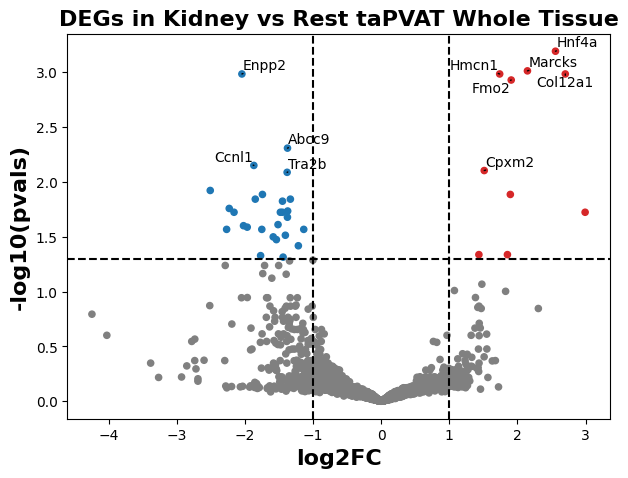

Comparing across Rest mesothelium in whole_tissue


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.89 seconds.

Fitting dispersion trend curve...
... done in 3.76 seconds.

Fitting MAP dispersions...
... done in 1.58 seconds.

Fitting LFCs...
... done in 2.08 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



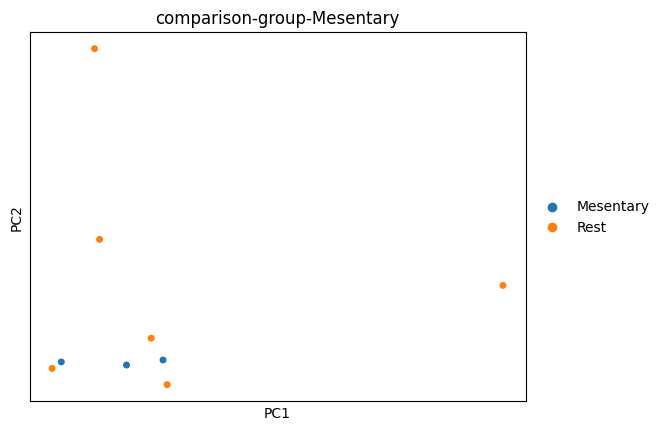

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 22.41 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.382260,-0.164919,2.353653,-0.070069,0.944138,NaN
3110082J24Rik,1.095163,-16.283001,277.672995,-0.058641,0.953238,NaN
4930455H04Rik,9.472874,0.695473,0.686485,1.013092,0.311016,NaN
4933400A11Rik,0.301683,-15.740122,279.531598,-0.056309,0.955096,NaN
4933403O08Rik,0.636978,1.474699,2.035669,0.724430,0.468802,NaN
...,...,...,...,...,...,...
mrpl24,8.578948,0.101816,0.591036,0.172266,0.863228,NaN
mrpl9,12.526063,0.647878,0.532816,1.215951,0.224004,NaN
pramef20l,1.844163,0.189834,1.233574,0.153890,0.877697,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:363: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/taPVAT_whole_tissue_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


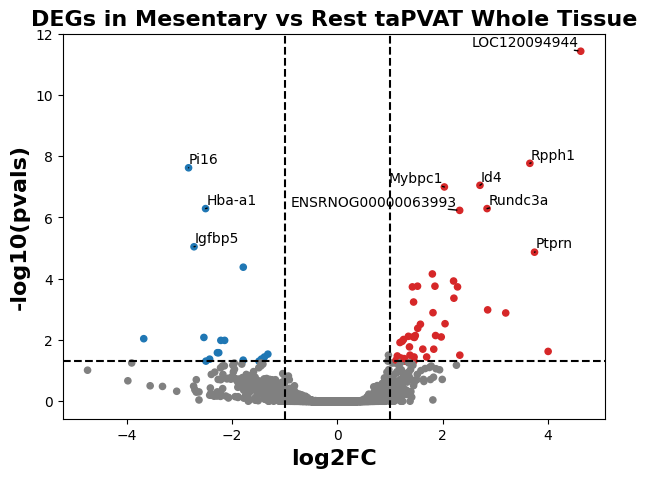

Comparing across Rest mesothelium in whole_tissue


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.49 seconds.

Fitting dispersion trend curve...
... done in 3.87 seconds.

Fitting MAP dispersions...
... done in 1.55 seconds.

Fitting LFCs...
... done in 1.84 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



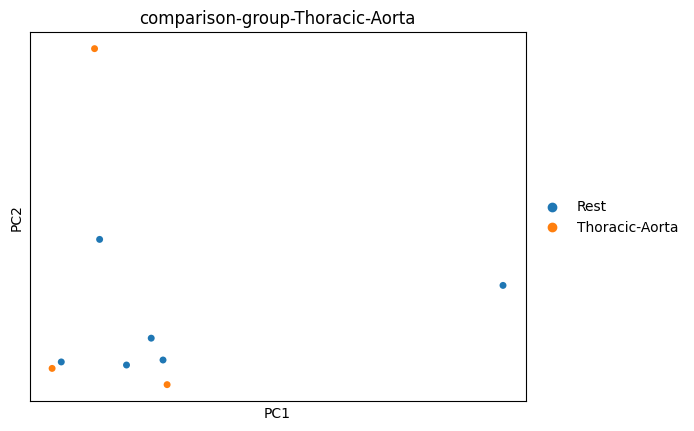

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 23.20 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.382260,-0.484235,2.334645,-0.207413,0.835688,NaN
3110082J24Rik,1.095163,1.957226,2.953250,0.662736,0.507500,NaN
4930455H04Rik,9.472874,-1.198000,0.764040,-1.567982,0.116885,0.387302
4933400A11Rik,0.301683,-17.458721,379.066057,-0.046057,0.963265,NaN
4933403O08Rik,0.636978,-18.251948,372.409967,-0.049010,0.960911,NaN
...,...,...,...,...,...,...
mrpl24,8.578948,0.062021,0.575603,0.107749,0.914195,0.964160
mrpl9,12.526063,-0.116517,0.555675,-0.209685,0.833913,0.929258
pramef20l,1.844163,-0.825046,1.312250,-0.628726,0.529528,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:363: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/taPVAT_whole_tissue_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


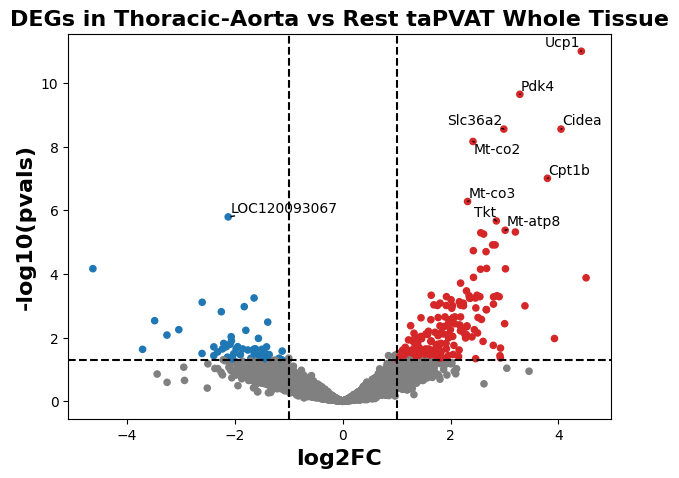

CPU times: user 1min 42s, sys: 2min 11s, total: 3min 53s
Wall time: 3min 15s


In [ ]:
%%time
### High level comparisons across whole-tissue
deseqRes = []

celltype = 'whole_tissue'
group_list = ['comparison-group-Kidney', 'comparison-group-Mesentery', 'comparison-group-Thoracic-Aorta']
group1_list = ['Rest', 'Rest', 'Rest']
group2_list = ['Kidney', 'Mesentery', 'Thoracic-Aorta']

for i in range(len(group_list)):
    print(f'Comparing across {group1_list[i]} mesothelium in {celltype}')
    
    adata_subset = adata.copy()
    celltype = celltype
    group = group_list[i]
    group1 = group1_list[i] 
    group2 = group2_list[i]
    
    ### Get the counts of cells per sample and check if any are less than 3
    sample_counts = adata_subset.obs['sample_id'].value_counts()
    failing_samples = sample_counts[sample_counts < 3]

    ### Check if there are any failing samples before moving on to DEG analysis
    if not failing_samples.empty:
        print("There are less than 3 cells of this cell type in the following samples:")
        print(failing_samples)
        deseqRes
    else:
        ### Run DESeq and save results
        de = return_de(adata, celltype, group, group1, group2)
        deseqRes.append(de)

        ### Generate and save volcano plots
        plot_volcano_df(de, celltype, group, group1, group2, return_fig = False, save = False)
        plot_volcano_df_html(de, celltype, group, group1, group2, return_fig = False, save = False)
        plt.show()

deseqResults1 = pd.concat(deseqRes)
deseqResults1.to_csv('../output/DEGs/Mesothelium_whole_tissue_vs_rest_deseq_.txt', sep = '\t')

Comparing across comparison-group-Kidney in taPVAT Endothelial_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.63 seconds.

Fitting dispersion trend curve...
... done in 3.27 seconds.

Fitting MAP dispersions...
... done in 1.48 seconds.

Fitting LFCs...
... done in 1.59 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


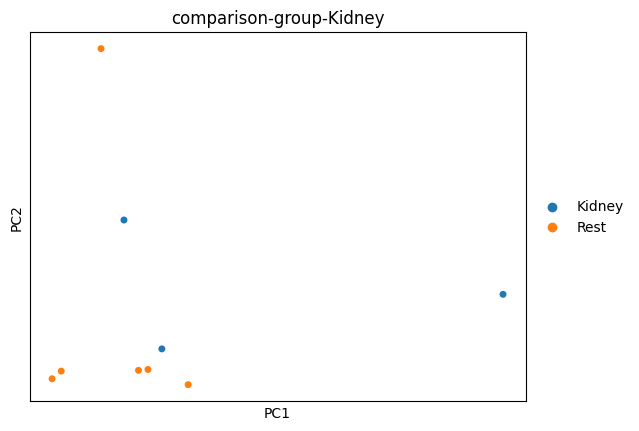

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 23.54 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.232445,-0.321545,1.219606,-0.263647,0.792052,0.999982
6330411D24Rik,10.680965,0.852573,0.499107,1.708198,0.087600,0.999982
A1bg,0.537644,0.971314,2.027970,0.478959,0.631968,0.999982
A1cf,4.832075,0.413641,0.670495,0.616919,0.537288,0.999982
A2m,2.945438,1.034819,0.897143,1.153461,0.248721,0.999982
...,...,...,...,...,...,...
Zzz3,6.260144,-0.459408,0.542710,-0.846507,0.397270,0.999982
mrpl11,0.344452,-2.640988,2.399712,-1.100544,0.271095,0.999982
mrpl24,1.276913,0.536525,1.192094,0.450069,0.652660,0.999982


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de['padj'] = de['padj'].iloc[:] + 1e-199


files saved to: ../output/DEGs/Mesothelium_Endothelial_Cells_Kidney_vs_Rest_comparison-group-Kidney_comparison....


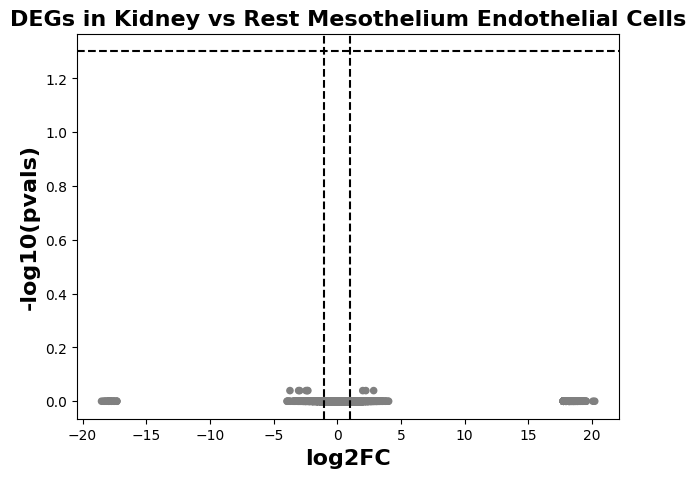

Comparing across comparison-group-Kidney in taPVAT Unknown


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.05 seconds.

Fitting dispersion trend curve...
... done in 2.90 seconds.

Fitting MAP dispersions...
... done in 1.16 seconds.

Fitting LFCs...
... done in 1.18 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



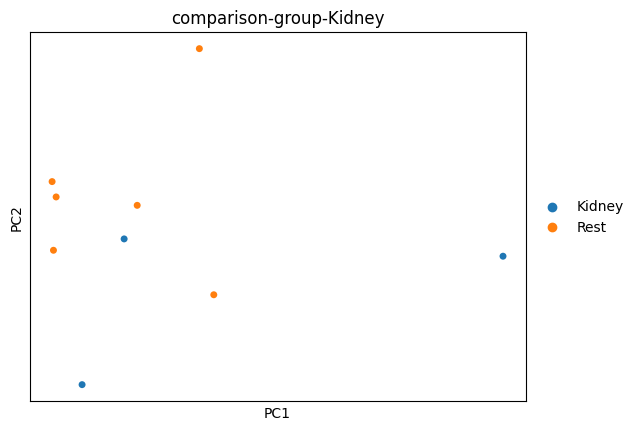

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 21.01 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.304882,0.392136,2.112887,0.185592,0.852764,NaN
6330411D24Rik,5.916571,0.799951,0.566807,1.411330,0.158147,NaN
A1cf,1.947462,0.807710,0.832807,0.969865,0.332114,NaN
A2m,1.339975,0.444263,0.943056,0.471088,0.637578,NaN
A2ml1,0.849846,1.639599,1.451927,1.129257,0.258790,NaN
...,...,...,...,...,...,...
Zzz3,4.477802,-0.257388,0.618985,-0.415822,0.677540,NaN
mrpl11,0.495232,-2.234650,2.111982,-1.058082,0.290018,NaN
mrpl24,0.482041,0.757751,1.638968,0.462334,0.643842,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Unknown_Kidney_vs_Rest_comparison-group-Kidney_comparison....


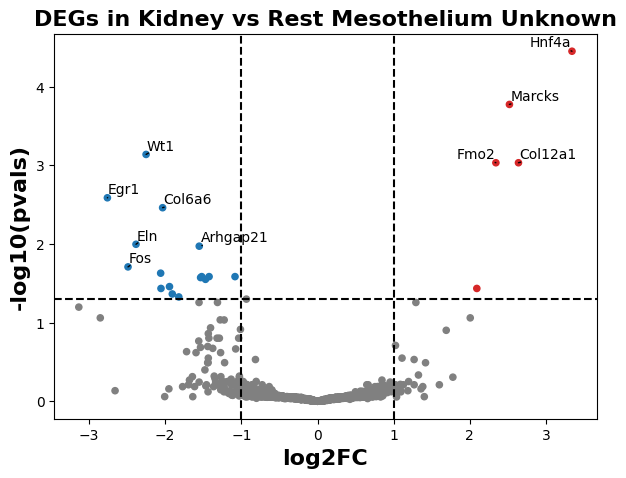

Comparing across comparison-group-Kidney in taPVAT Immune_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.06 seconds.

Fitting dispersion trend curve...
... done in 2.97 seconds.

Fitting MAP dispersions...
... done in 1.02 seconds.

Fitting LFCs...
... done in 0.90 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



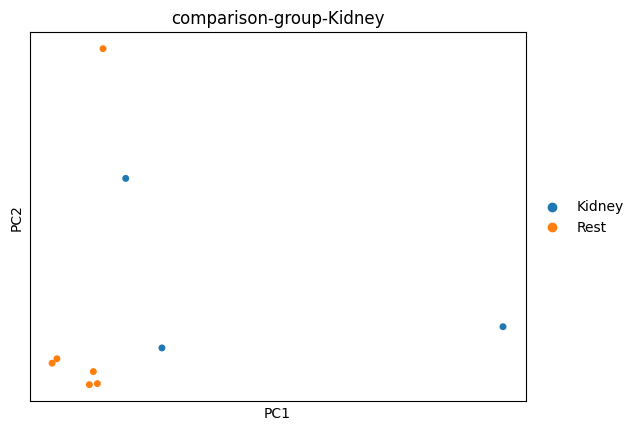

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 20.78 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.794741,-0.607728,1.467040,-0.414255,0.678687,0.999623
6330411D24Rik,8.978828,0.146831,0.539066,0.272380,0.785330,0.999623
A1cf,2.638937,-0.300899,0.881535,-0.341335,0.732851,0.999623
A2m,1.781484,0.814527,1.022248,0.796800,0.425567,0.999623
A2ml1,0.703694,0.040722,1.371719,0.029687,0.976317,0.999623
...,...,...,...,...,...,...
mrpl11,0.241372,-0.724026,2.119321,-0.341631,0.732629,0.999623
mrpl24,0.354833,1.597436,2.007078,0.795901,0.426089,0.999623
mrpl9,0.884681,-0.443343,1.328467,-0.333725,0.738587,0.999623


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Immune_Cells_Kidney_vs_Rest_comparison-group-Kidney_comparison....


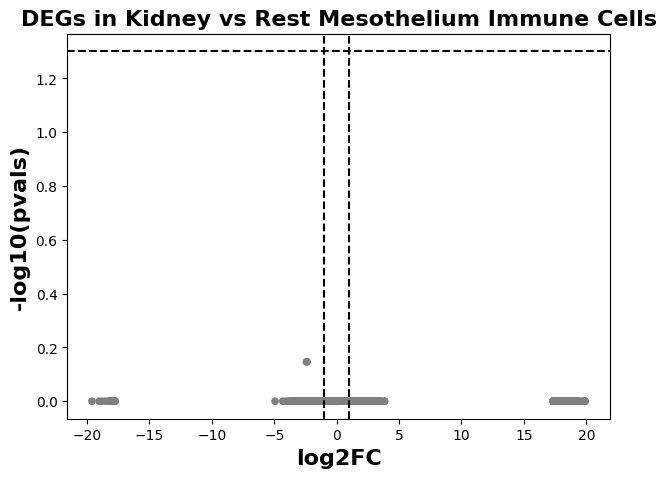

Comparing across comparison-group-Kidney in taPVAT Mesothelial_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.78 seconds.

Fitting dispersion trend curve...
... done in 3.19 seconds.

Fitting MAP dispersions...
... done in 1.63 seconds.

Fitting LFCs...
... done in 1.95 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



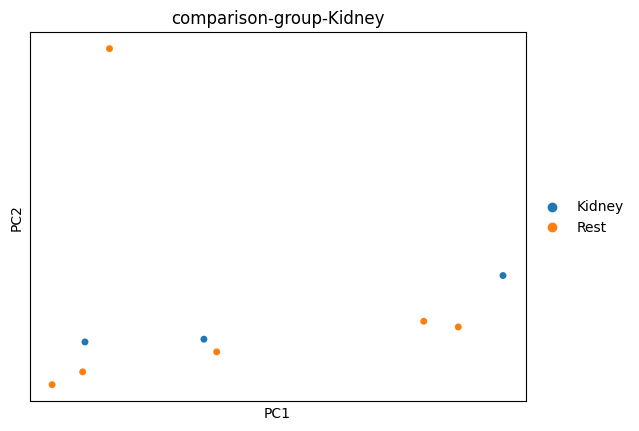

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 21.16 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.958965,1.373847,1.067787,1.286631,0.198223,NaN
6330411D24Rik,18.329498,0.595840,0.505253,1.179290,0.238283,0.931928
A1bg,0.256220,-0.233836,2.736043,-0.085465,0.931892,NaN
A1cf,3.614438,0.380720,0.755601,0.503864,0.614357,NaN
A2m,2.202062,0.793889,0.988797,0.802884,0.422042,NaN
...,...,...,...,...,...,...
hist1h2ail2,0.615788,0.670034,1.655549,0.404720,0.685683,NaN
mrpl11,0.230146,-1.282335,2.876577,-0.445785,0.655753,NaN
mrpl24,1.587699,-0.965741,1.108265,-0.871399,0.383536,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Mesothelial_Cells_Kidney_vs_Rest_comparison-group-Kidney_comparison....


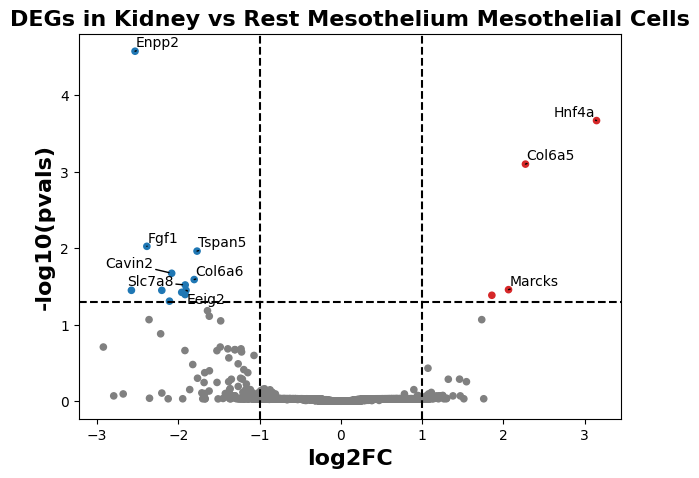

Comparing across comparison-group-Kidney in taPVAT Fibroblasts


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.37 seconds.

Fitting dispersion trend curve...
... done in 3.56 seconds.

Fitting MAP dispersions...
... done in 1.54 seconds.

Fitting LFCs...
... done in 1.66 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



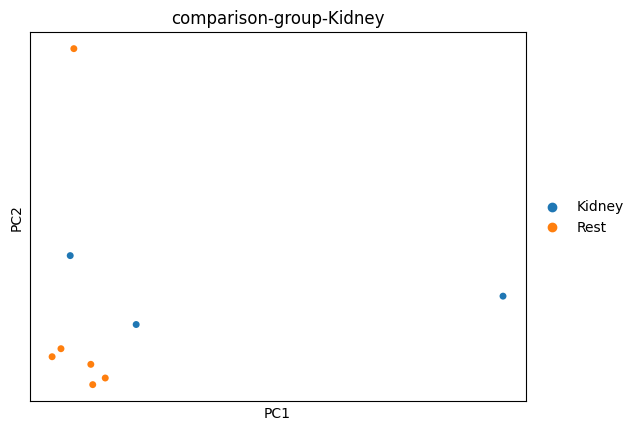

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 20.45 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.457864,1.291863,1.369874,0.943052,0.345654,NaN
6330411D24Rik,17.333103,1.166624,0.494855,2.357505,0.018398,0.55525
A1cf,4.181524,0.526338,0.648374,0.811780,0.416918,NaN
A2m,2.036559,0.813272,0.898487,0.905157,0.365382,NaN
A2ml1,1.709437,0.774406,0.936372,0.827028,0.408221,NaN
...,...,...,...,...,...,...
mrpl11,0.749869,0.480671,1.369083,0.351090,0.725521,NaN
mrpl24,1.919095,-0.380465,0.880850,-0.431929,0.665793,NaN
mrpl9,2.891434,-0.226854,0.755348,-0.300330,0.763925,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Fibroblasts_Kidney_vs_Rest_comparison-group-Kidney_comparison....


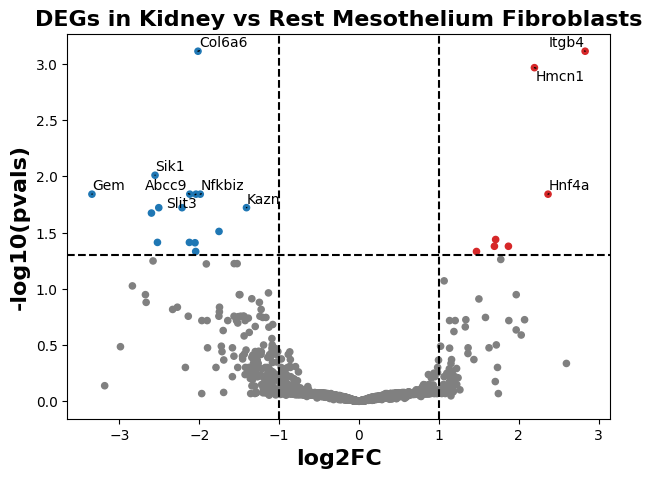

Comparing across comparison-group-Kidney in taPVAT Pericytes_SMCs


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.69 seconds.

Fitting dispersion trend curve...
... done in 3.05 seconds.

Fitting MAP dispersions...
... done in 1.74 seconds.

Fitting LFCs...
... done in 2.00 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



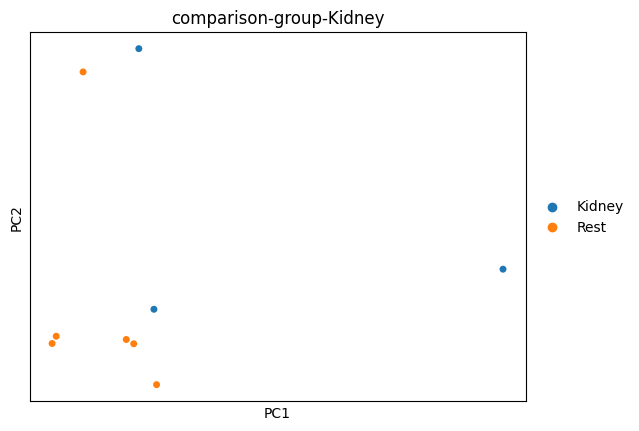

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 22.76 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.561672,-0.720409,1.241874,-0.580098,0.561849,0.99976
6330411D24Rik,14.380771,-0.085647,0.462769,-0.185076,0.853170,0.99976
A1cf,5.093946,0.298837,0.589664,0.506792,0.612301,0.99976
A2m,1.975557,0.741742,0.814936,0.910185,0.362725,0.99976
A2ml1,1.267973,2.275260,1.144880,1.987335,0.046885,0.99976
...,...,...,...,...,...,...
dsr-2,0.411393,-17.917376,266.611474,-0.067204,0.946419,0.99976
mrpl11,0.238588,-1.284881,2.434597,-0.527759,0.597666,0.99976
mrpl24,0.590564,-0.054232,1.462286,-0.037087,0.970415,0.99976


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Pericytes_SMCs_Kidney_vs_Rest_comparison-group-Kidney_comparison....


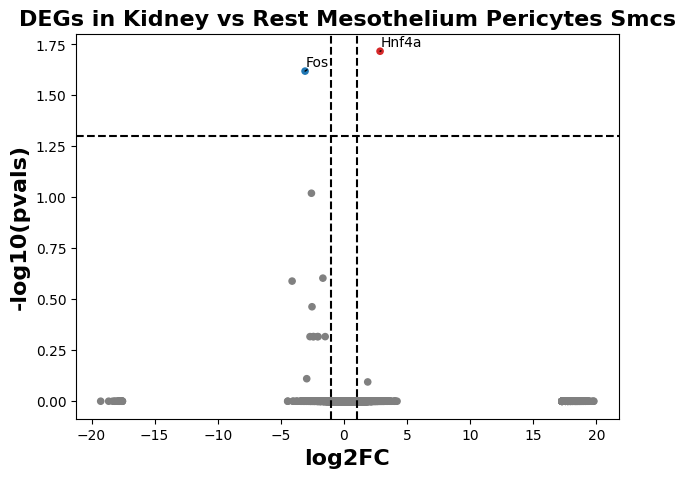

Comparing across comparison-group-Kidney in taPVAT Adipocytes_White


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.38 seconds.

Fitting dispersion trend curve...
... done in 2.74 seconds.

Fitting MAP dispersions...
... done in 1.40 seconds.

Fitting LFCs...
... done in 1.36 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



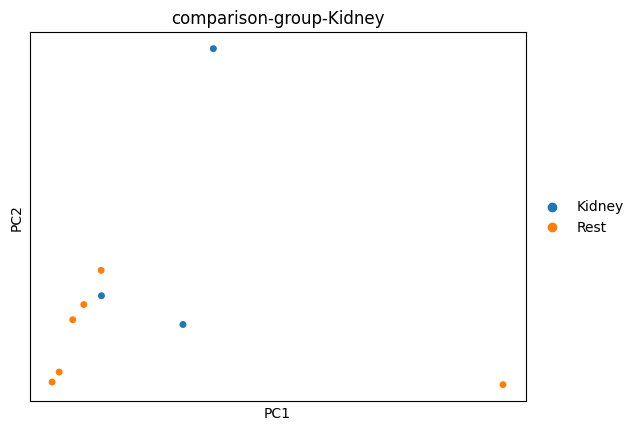

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 21.30 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.195096,-1.024457,2.821343,-0.363110,0.716523,0.999989
4930455H04Rik,0.447868,-0.089038,1.905297,-0.046732,0.962727,0.999989
6330411D24Rik,7.938456,0.514667,0.770743,0.667754,0.504290,0.999989
A1cf,2.579995,-0.379153,0.925875,-0.409507,0.682167,0.999989
A2m,0.924496,0.830857,1.372011,0.605576,0.544797,0.999989
...,...,...,...,...,...,...
Zzz3,3.591668,-0.908897,0.796067,-1.141734,0.253565,0.999989
mrpl11,0.505742,0.647434,1.916810,0.337766,0.735539,0.999989
mrpl24,0.261867,2.202449,2.501716,0.880375,0.378656,0.999989


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_White_Kidney_vs_Rest_comparison-group-Kidney_comparison....


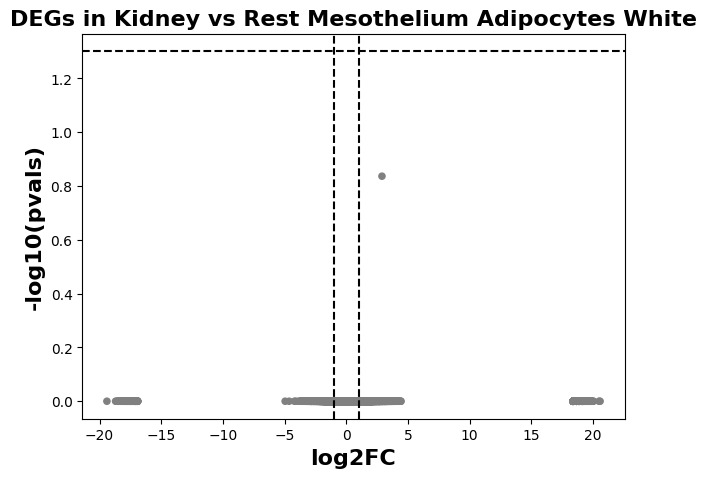

Comparing across comparison-group-Kidney in taPVAT Schwann_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.30 seconds.

Fitting dispersion trend curve...
... done in 2.62 seconds.

Fitting MAP dispersions...
... done in 1.27 seconds.

Fitting LFCs...
... done in 1.24 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



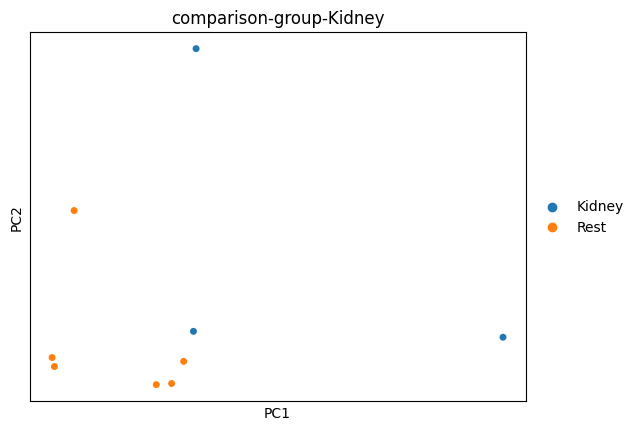

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 20.18 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.553353,-1.882804,2.175488,-0.865463,0.386785,1.0
6330411D24Rik,4.947484,0.513698,0.534855,0.960443,0.336832,1.0
A1cf,1.591195,1.058605,0.954962,1.108531,0.267633,1.0
A2m,1.027405,0.250769,0.998055,0.251258,0.801615,1.0
A2ml1,0.479246,1.298882,1.602864,0.810351,0.417739,1.0
...,...,...,...,...,...,...
Zyx,2.905440,-0.991609,0.803775,-1.233690,0.217318,1.0
Zzef1,3.594330,0.298942,0.654070,0.457049,0.647636,1.0
Zzz3,2.472987,-0.841015,0.820451,-1.025065,0.305332,1.0


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Schwann_Cells_Kidney_vs_Rest_comparison-group-Kidney_comparison....


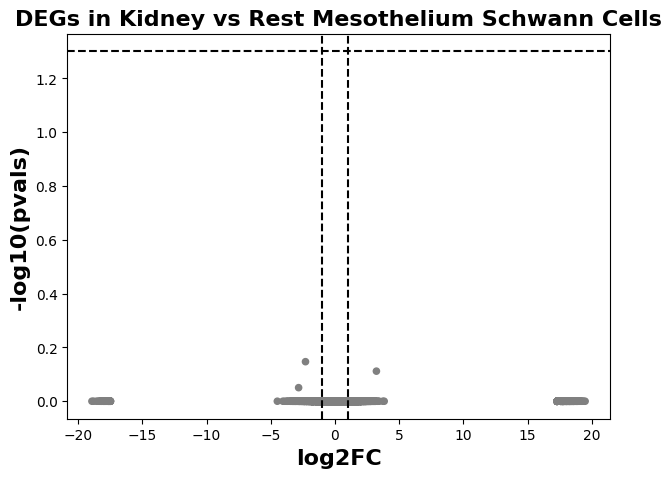

Comparing across comparison-group-Kidney in taPVAT Adipocytes_Brown


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.32 seconds.

Fitting dispersion trend curve...
... done in 2.53 seconds.

Fitting MAP dispersions...
... done in 1.22 seconds.

Fitting LFCs...
... done in 1.32 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



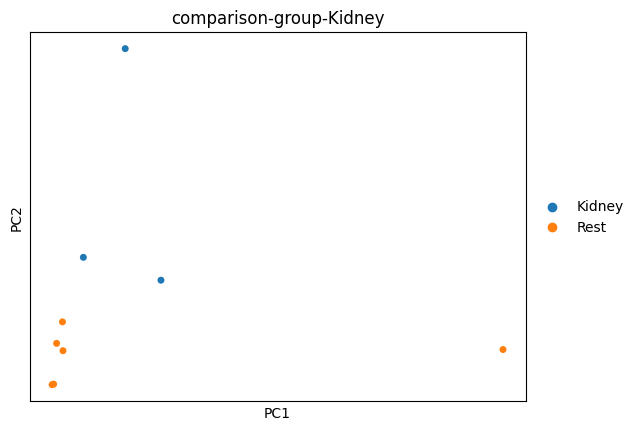

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Kidney Kidney vs Rest


... done in 21.16 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.291871,1.124214,2.303905,0.487960,0.625578,0.99966
6330411D24Rik,4.815761,0.540495,0.837545,0.645333,0.518712,0.99966
A1cf,1.178550,1.706668,1.412207,1.208511,0.226851,0.99966
A2m,1.383717,0.384864,1.386247,0.277630,0.781296,0.99966
A2ml1,1.765043,-0.174846,1.350800,-0.129439,0.897010,0.99966
...,...,...,...,...,...,...
Zzz3,2.331144,-0.912249,1.027181,-0.888110,0.374482,0.99966
mrpl11,0.722204,-1.227157,1.662102,-0.738316,0.460322,0.99966
mrpl24,0.492471,-0.135233,1.847432,-0.073200,0.941647,0.99966


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_Brown_Kidney_vs_Rest_comparison-group-Kidney_comparison....


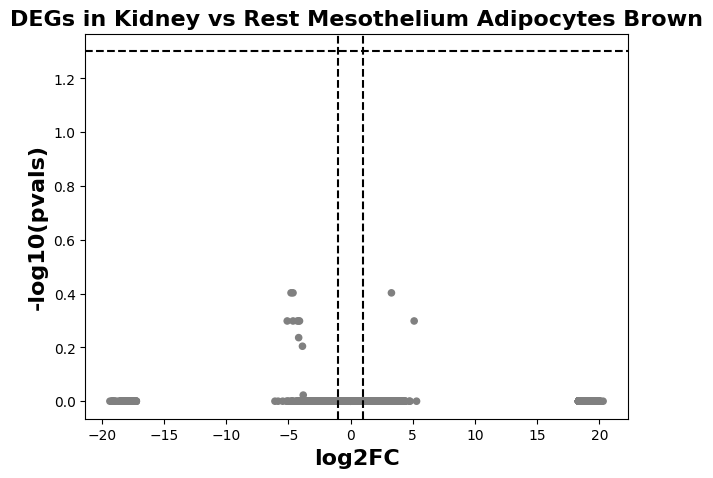

Comparing across comparison-group-Mesentary in taPVAT Endothelial_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.64 seconds.

Fitting dispersion trend curve...
... done in 3.08 seconds.

Fitting MAP dispersions...
... done in 1.48 seconds.

Fitting LFCs...
... done in 1.74 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



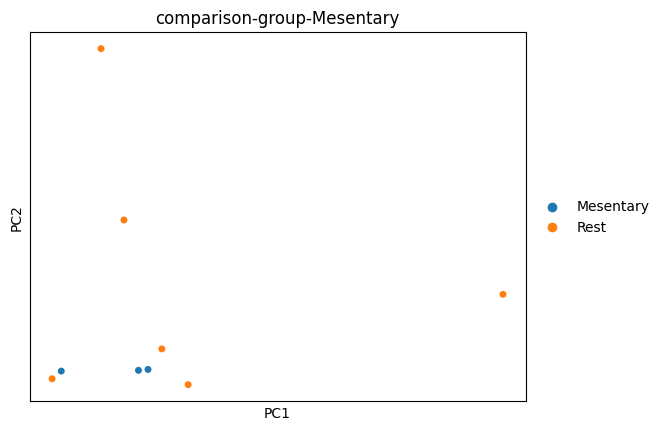

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 21.84 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.232445,0.887548,1.347760,0.658536,0.510194,NaN
6330411D24Rik,10.680965,-0.290725,0.604806,-0.480691,0.630736,0.999055
A1bg,0.537644,1.278713,2.023737,0.631858,0.527480,NaN
A1cf,4.832075,0.515245,0.729132,0.706656,0.479781,0.999055
A2m,2.945438,-0.126665,1.007076,-0.125775,0.899910,NaN
...,...,...,...,...,...,...
Zzz3,6.260144,0.122924,0.649346,0.189304,0.849854,0.999055
mrpl11,0.344452,0.005638,2.396104,0.002353,0.998123,NaN
mrpl24,1.276913,-0.327703,1.451066,-0.225836,0.821329,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Endothelial_Cells_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


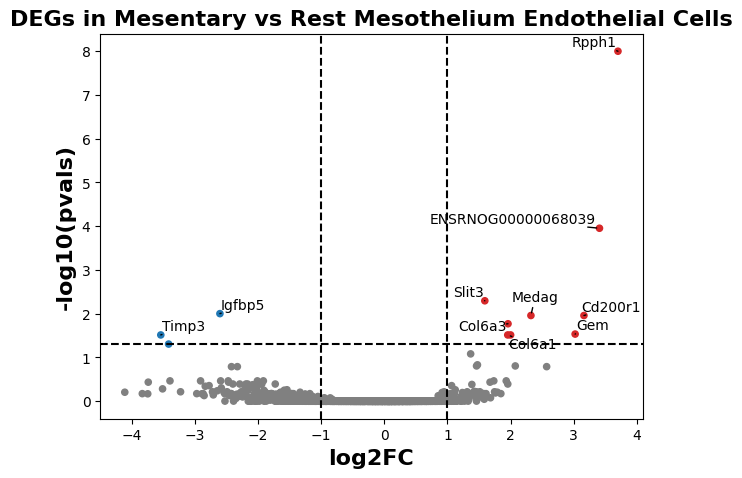

Comparing across comparison-group-Mesentary in taPVAT Unknown


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.06 seconds.

Fitting dispersion trend curve...
... done in 2.91 seconds.

Fitting MAP dispersions...
... done in 1.13 seconds.

Fitting LFCs...
... done in 1.18 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



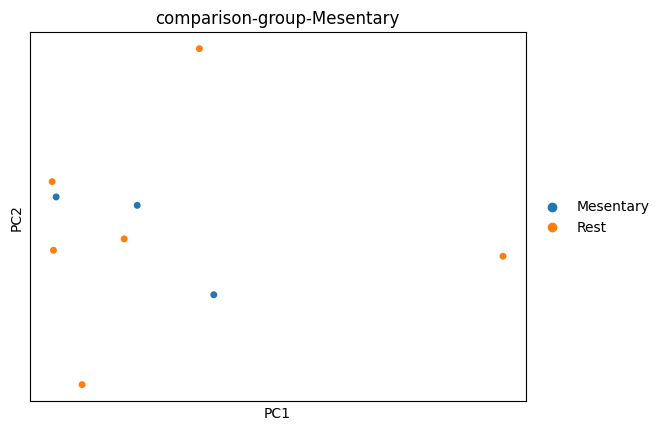

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 22.59 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.304882,0.878894,2.256904,0.389425,0.696962,0.999529
6330411D24Rik,5.916571,-0.213170,0.632392,-0.337085,0.736053,0.999529
A1cf,1.947462,-0.071932,0.920684,-0.078128,0.937726,0.999529
A2m,1.339975,0.033126,1.043097,0.031758,0.974665,0.999529
A2ml1,0.849846,-0.236027,1.507497,-0.156569,0.875585,0.999529
...,...,...,...,...,...,...
Zzz3,4.477802,0.301906,0.688611,0.438427,0.661077,0.999529
mrpl11,0.495232,1.564863,1.993842,0.784848,0.432543,0.999529
mrpl24,0.482041,0.525107,1.779818,0.295034,0.767968,0.999529


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Unknown_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


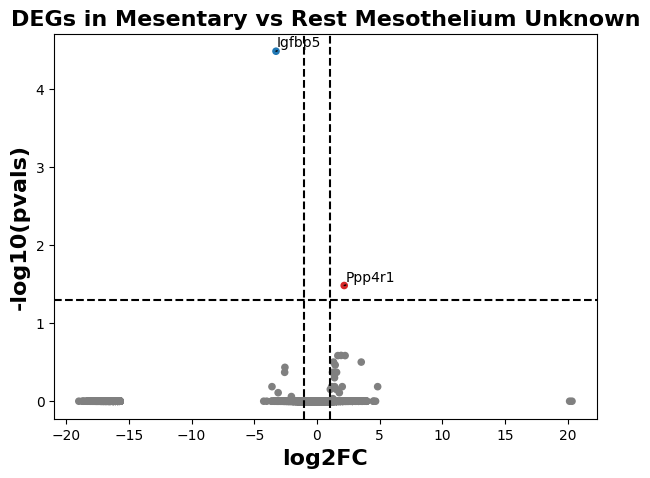

Comparing across comparison-group-Mesentary in taPVAT Immune_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.14 seconds.

Fitting dispersion trend curve...
... done in 2.81 seconds.

Fitting MAP dispersions...
... done in 0.89 seconds.

Fitting LFCs...
... done in 1.02 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



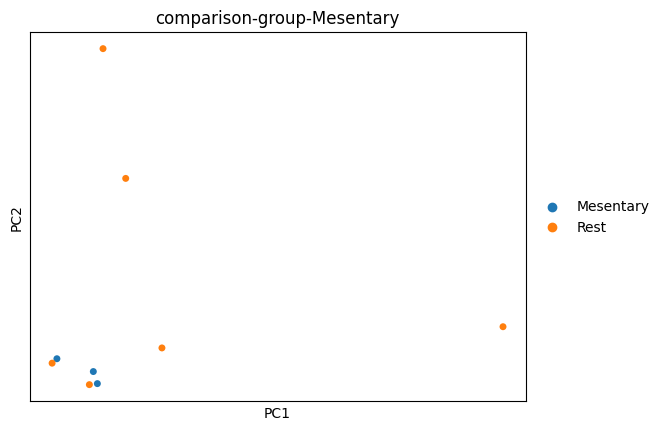

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 20.83 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.794741,1.150879,1.572252,0.731994,0.464172,0.998966
6330411D24Rik,8.978828,0.301727,0.585662,0.515190,0.606420,0.998966
A1cf,2.638937,1.435286,0.876043,1.638374,0.101344,0.998966
A2m,1.781484,0.211869,1.125767,0.188200,0.850720,0.998966
A2ml1,0.703694,-0.786965,1.874702,-0.419781,0.674645,0.998966
...,...,...,...,...,...,...
mrpl11,0.241372,1.043937,2.395089,0.435866,0.662934,0.998966
mrpl24,0.354833,-15.853526,280.133350,-0.056593,0.954870,0.998966
mrpl9,0.884681,0.355322,1.507710,0.235670,0.813689,0.998966


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Immune_Cells_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


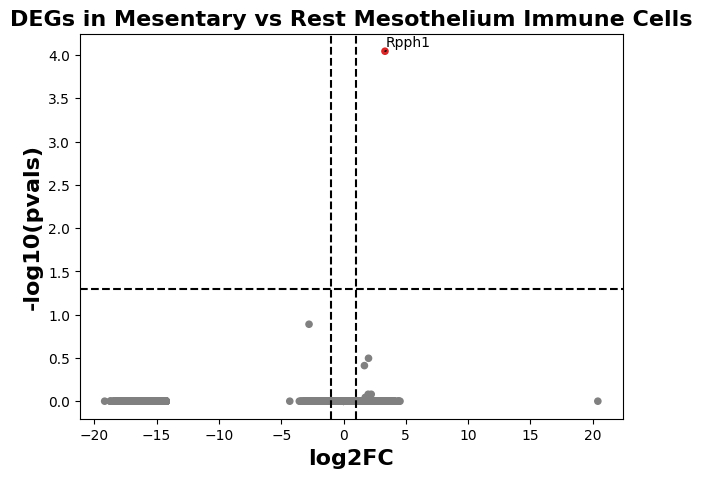

Comparing across comparison-group-Mesentary in taPVAT Mesothelial_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.79 seconds.

Fitting dispersion trend curve...
... done in 3.20 seconds.

Fitting MAP dispersions...
... done in 1.80 seconds.

Fitting LFCs...
... done in 1.87 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



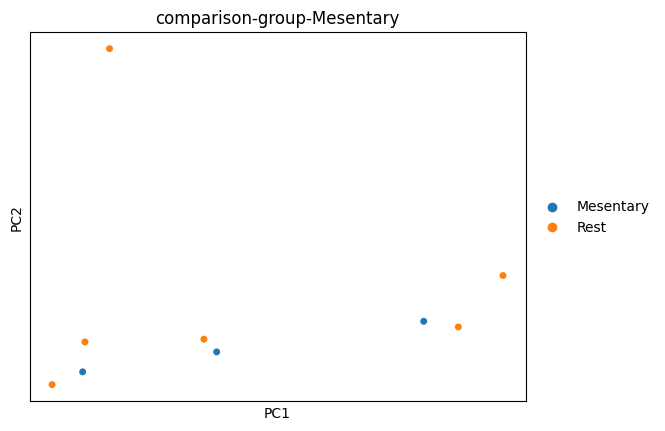

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 21.03 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.958965,0.357031,1.125329,0.317268,0.751040,0.999981
6330411D24Rik,18.329498,0.140763,0.532206,0.264489,0.791403,0.999981
A1bg,0.256220,2.351335,2.674679,0.879109,0.379342,0.999981
A1cf,3.614438,0.334661,0.783866,0.426936,0.669426,0.999981
A2m,2.202062,0.108962,1.046785,0.104092,0.917096,0.999981
...,...,...,...,...,...,...
hist1h2ail2,0.615788,-1.336635,1.986423,-0.672885,0.501020,0.999981
mrpl11,0.230146,-0.473176,2.841125,-0.166545,0.867728,0.999981
mrpl24,1.587699,0.856937,1.050397,0.815822,0.414602,0.999981


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Mesothelial_Cells_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


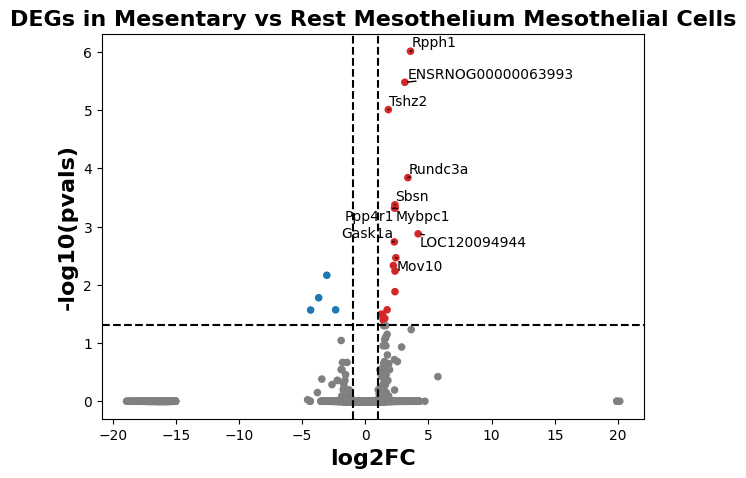

Comparing across comparison-group-Mesentary in taPVAT Fibroblasts


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.46 seconds.

Fitting dispersion trend curve...
... done in 3.24 seconds.

Fitting MAP dispersions...
... done in 1.42 seconds.

Fitting LFCs...
... done in 1.51 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



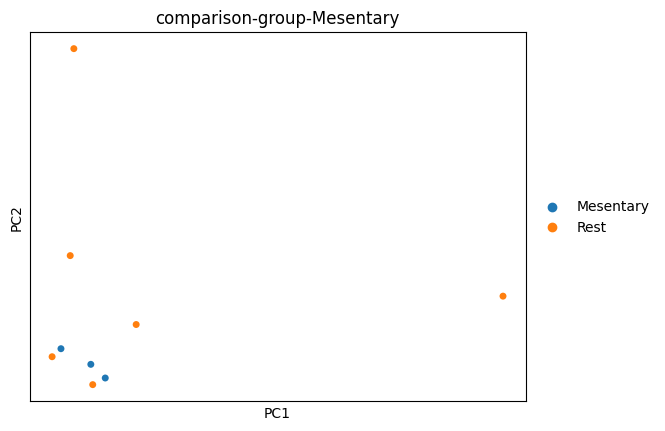

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 21.55 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.457864,-0.212944,1.436219,-0.148267,0.882132,NaN
6330411D24Rik,17.333103,-0.280932,0.571482,-0.491586,0.623012,0.999073
A1cf,4.181524,0.331680,0.739918,0.448266,0.653961,NaN
A2m,2.036559,0.281748,0.998677,0.282122,0.777850,NaN
A2ml1,1.709437,0.014220,1.059274,0.013424,0.989290,NaN
...,...,...,...,...,...,...
mrpl11,0.749869,0.217762,1.513975,0.143834,0.885631,NaN
mrpl24,1.919095,0.637029,0.963995,0.660822,0.508726,NaN
mrpl9,2.891434,0.068376,0.856241,0.079856,0.936352,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Fibroblasts_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


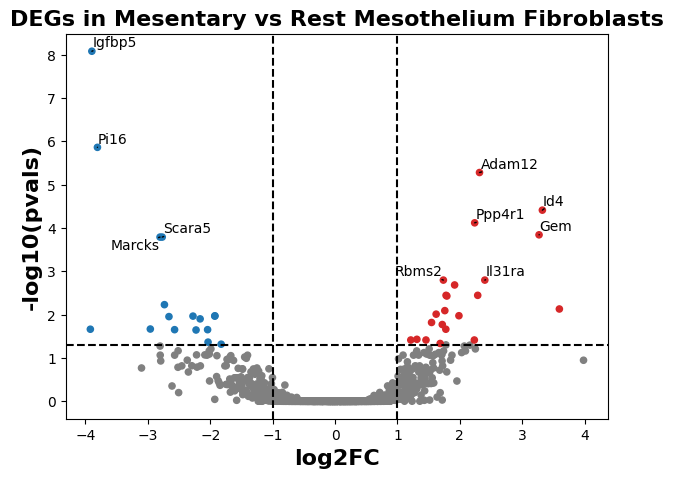

Comparing across comparison-group-Mesentary in taPVAT Pericytes_SMCs


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.67 seconds.

Fitting dispersion trend curve...
... done in 3.10 seconds.

Fitting MAP dispersions...
... done in 1.59 seconds.

Fitting LFCs...
... done in 1.72 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



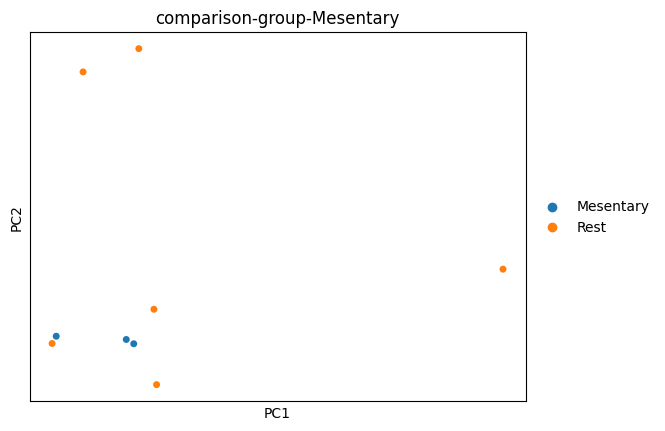

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 20.77 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.561672,0.486942,1.389848,0.350356,0.726071,0.999843
6330411D24Rik,14.380771,0.755029,0.475860,1.586662,0.112589,0.999843
A1cf,5.093946,0.192685,0.700950,0.274891,0.783400,0.999843
A2m,1.975557,-0.207115,1.026126,-0.201842,0.840041,0.999843
A2ml1,1.267973,-1.080586,1.429923,-0.755695,0.449832,0.999843
...,...,...,...,...,...,...
dsr-2,0.411393,0.259552,2.323188,0.111722,0.911044,0.999843
mrpl11,0.238588,1.052942,2.630843,0.400230,0.688987,0.999843
mrpl24,0.590564,0.408427,1.699322,0.240347,0.810061,0.999843


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Pericytes_SMCs_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


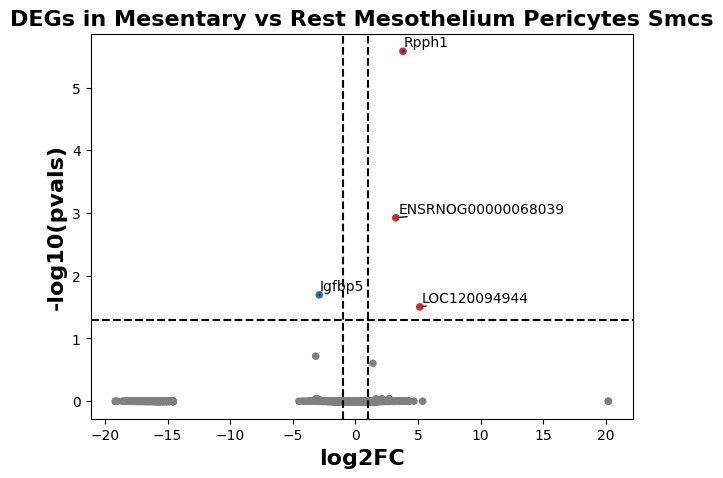

Comparing across comparison-group-Mesentary in taPVAT Adipocytes_White


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.34 seconds.

Fitting dispersion trend curve...
... done in 2.59 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 1.30 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



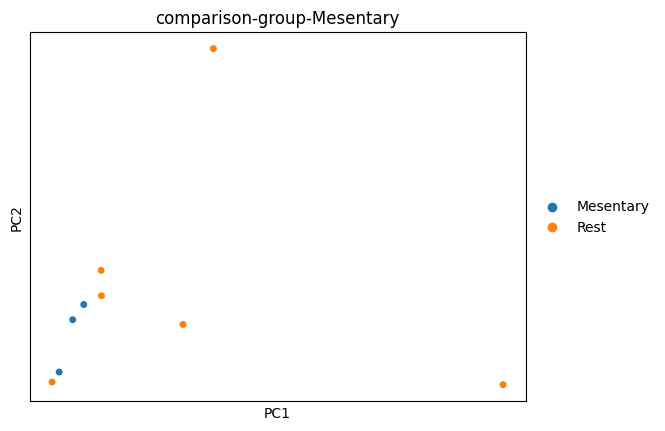

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 21.27 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.195096,1.989371,2.844693,0.699327,0.484348,0.999889
4930455H04Rik,0.447868,1.684978,1.963325,0.858227,0.390767,0.999889
6330411D24Rik,7.938456,0.413017,0.787332,0.524578,0.599876,0.999889
A1cf,2.579995,0.968888,0.973418,0.995346,0.319568,0.999889
A2m,0.924496,0.314956,1.544294,0.203948,0.838394,0.999889
...,...,...,...,...,...,...
Zzz3,3.591668,-0.022662,0.930421,-0.024357,0.980568,0.999889
mrpl11,0.505742,-16.145501,279.457564,-0.057774,0.953928,0.999889
mrpl24,0.261867,-15.182313,282.840553,-0.053678,0.957192,0.999889


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_White_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


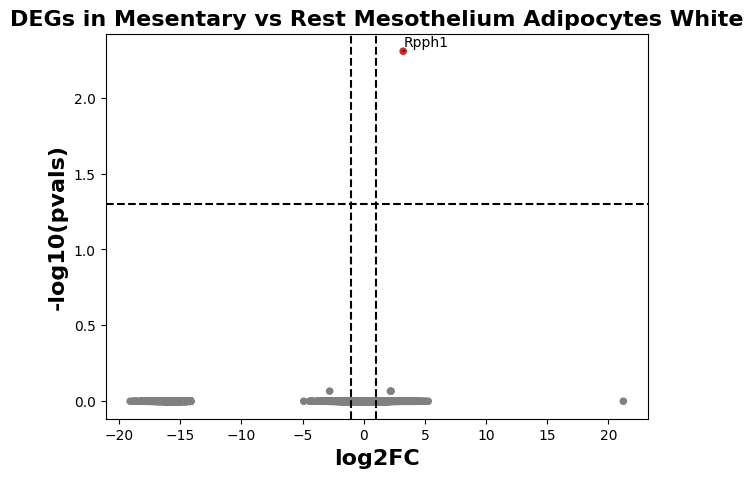

Comparing across comparison-group-Mesentary in taPVAT Schwann_Cells


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.25 seconds.

Fitting dispersion trend curve...
... done in 2.41 seconds.

Fitting MAP dispersions...
... done in 1.15 seconds.

Fitting LFCs...
... done in 1.30 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



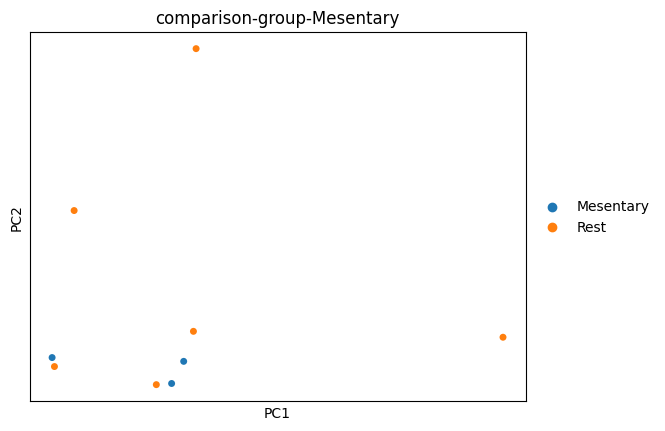

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 20.10 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.553353,1.231392,2.132874,0.577339,0.563710,0.999941
6330411D24Rik,4.947484,-0.865855,0.690607,-1.253760,0.209929,0.999941
A1cf,1.591195,-1.611923,1.320804,-1.220411,0.222309,0.999941
A2m,1.027405,0.547395,1.180699,0.463620,0.642920,0.999941
A2ml1,0.479246,0.051751,1.837709,0.028161,0.977534,0.999941
...,...,...,...,...,...,...
Zyx,2.905440,-0.183261,0.946114,-0.193699,0.846412,0.999941
Zzef1,3.594330,-0.292854,0.771708,-0.379489,0.704325,0.999941
Zzz3,2.472987,-0.278912,0.970077,-0.287516,0.773717,0.999941


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Schwann_Cells_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


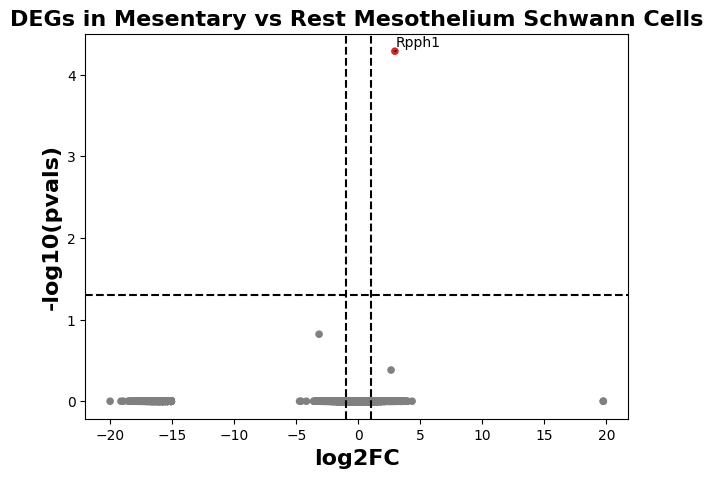

Comparing across comparison-group-Mesentary in taPVAT Adipocytes_Brown


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.34 seconds.

Fitting dispersion trend curve...
... done in 2.54 seconds.

Fitting MAP dispersions...
... done in 1.24 seconds.

Fitting LFCs...
... done in 1.33 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



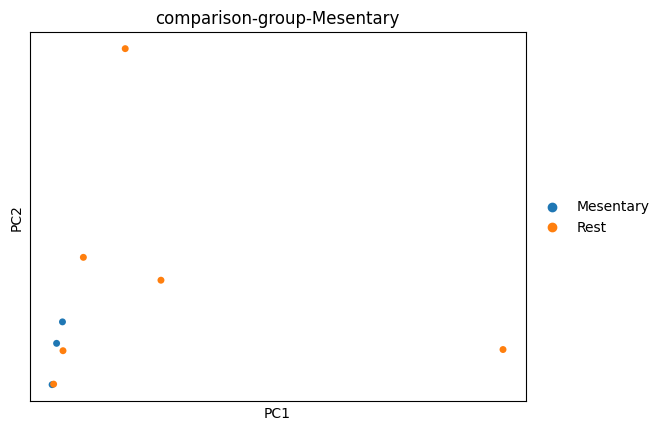

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Mesentary Mesentary vs Rest


... done in 19.99 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.291871,0.945133,2.473756,0.382064,0.702414,0.999652
6330411D24Rik,4.815761,0.485209,0.910664,0.532808,0.594166,0.999652
A1cf,1.178550,0.345886,1.521921,0.227270,0.820214,0.999652
A2m,1.383717,-0.809471,1.762227,-0.459345,0.645986,0.999652
A2ml1,1.765043,-17.073803,276.523654,-0.061744,0.950766,0.999652
...,...,...,...,...,...,...
Zzz3,2.331144,0.020881,1.188550,0.017568,0.985983,0.999652
mrpl11,0.722204,-16.136724,279.714132,-0.057690,0.953996,0.999652
mrpl24,0.492471,-16.159542,279.635387,-0.057788,0.953918,0.999652


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_Brown_Mesentary_vs_Rest_comparison-group-Mesentary_comparison....


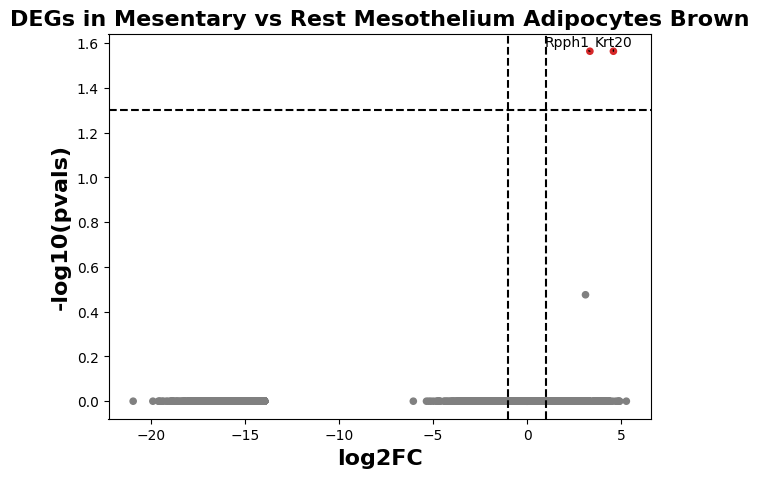

Comparing across comparison-group-Thoracic-Aorta in taPVAT Endothelial_Cells


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 3.06 seconds.

Fitting MAP dispersions...
... done in 1.49 seconds.

Fitting LFCs...
... done in 1.78 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



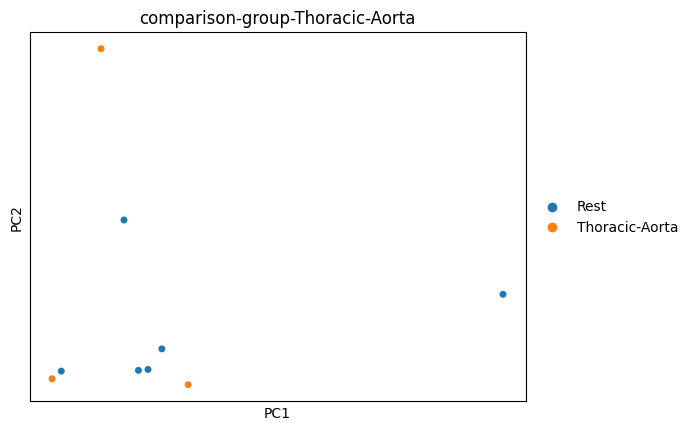

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 20.70 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.232445,-0.630712,1.451117,-0.434639,0.663825,NaN
6330411D24Rik,10.680965,-0.832456,0.560712,-1.484640,0.137639,NaN
A1bg,0.537644,-17.359475,383.049294,-0.045319,0.963853,NaN
A1cf,4.832075,-1.153481,0.765409,-1.507012,0.131808,NaN
A2m,2.945438,-1.439946,1.053831,-1.366391,0.171816,NaN
...,...,...,...,...,...,...
Zzz3,6.260144,0.379068,0.592591,0.639679,0.522381,NaN
mrpl11,0.344452,1.987844,2.228211,0.892125,0.372326,NaN
mrpl24,1.276913,-0.371384,1.365106,-0.272055,0.785580,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Endothelial_Cells_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


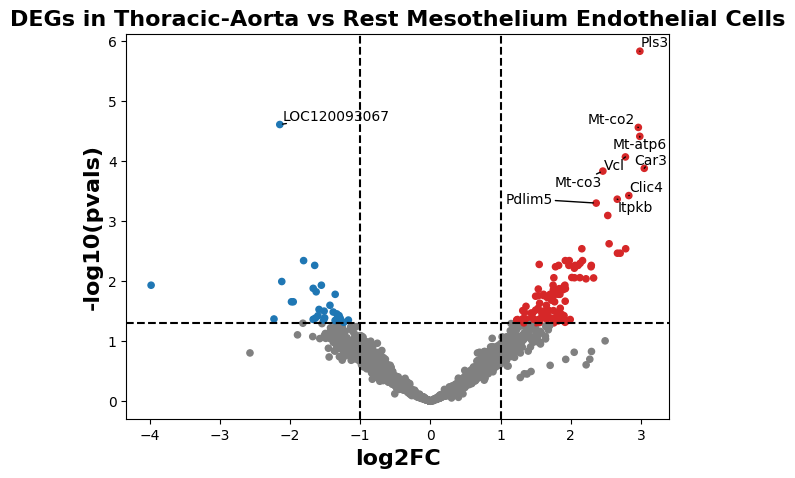

Comparing across comparison-group-Thoracic-Aorta in taPVAT Unknown


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.08 seconds.

Fitting dispersion trend curve...
... done in 2.91 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 1.21 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



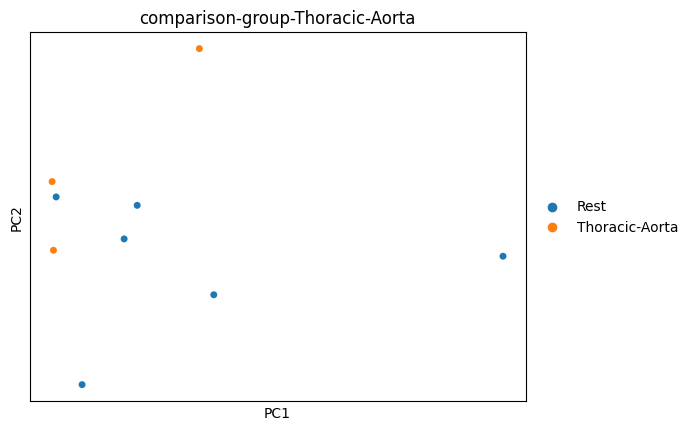

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 20.54 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.304882,-16.776641,389.459059,-0.043077,0.965640,NaN
6330411D24Rik,5.916571,-0.984575,0.692526,-1.421715,0.155109,0.993148
A1cf,1.947462,-1.316316,1.141213,-1.153436,0.248732,NaN
A2m,1.339975,-0.749719,1.223843,-0.612594,0.540145,NaN
A2ml1,0.849846,-17.846056,379.487971,-0.047027,0.962492,NaN
...,...,...,...,...,...,...
Zzz3,4.477802,0.038669,0.731539,0.052859,0.957844,0.997804
mrpl11,0.495232,0.511017,2.146000,0.238125,0.811784,NaN
mrpl24,0.482041,-17.370372,383.834797,-0.045255,0.963904,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Unknown_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


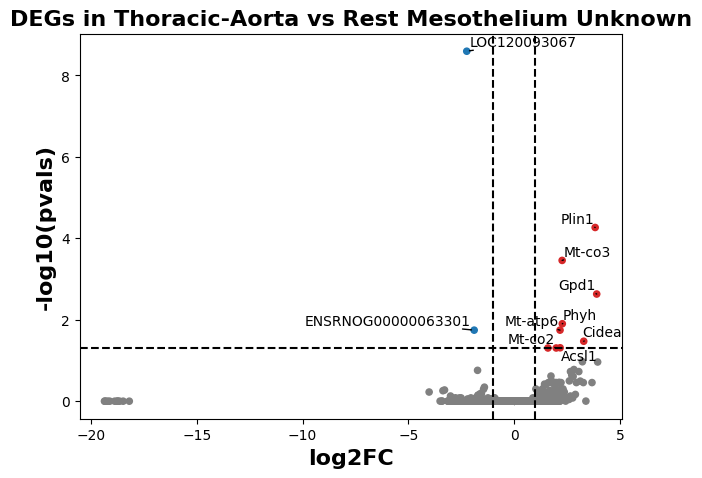

Comparing across comparison-group-Thoracic-Aorta in taPVAT Immune_Cells


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.86 seconds.

Fitting dispersion trend curve...
... done in 2.99 seconds.

Fitting MAP dispersions...
... done in 1.16 seconds.

Fitting LFCs...
... done in 0.98 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



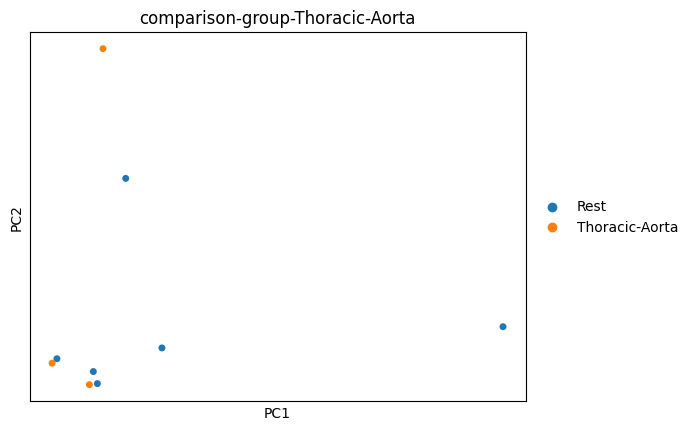

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 20.48 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.794741,-0.545721,1.847025,-0.295459,0.767643,NaN
6330411D24Rik,8.978828,-0.546191,0.614549,-0.888767,0.374129,0.779639
A1cf,2.638937,-2.007240,1.272170,-1.577809,0.114610,NaN
A2m,1.781484,-1.695635,1.363264,-1.243806,0.213571,NaN
A2ml1,0.703694,0.563385,1.611336,0.349639,0.726610,NaN
...,...,...,...,...,...,...
mrpl11,0.241372,-0.309679,2.762274,-0.112110,0.910736,NaN
mrpl24,0.354833,-0.262550,2.308817,-0.113716,0.909463,NaN
mrpl9,0.884681,0.236307,1.542525,0.153195,0.878244,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Immune_Cells_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


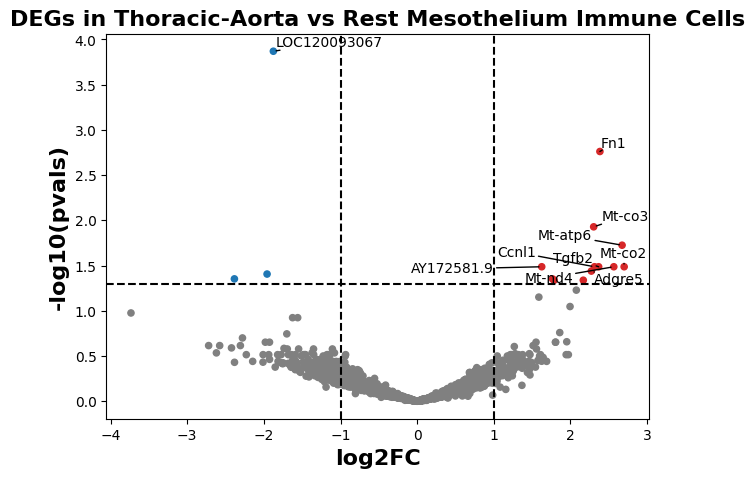

Comparing across comparison-group-Thoracic-Aorta in taPVAT Mesothelial_Cells


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.95 seconds.

Fitting dispersion trend curve...
... done in 3.44 seconds.

Fitting MAP dispersions...
... done in 1.90 seconds.

Fitting LFCs...
... done in 2.19 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



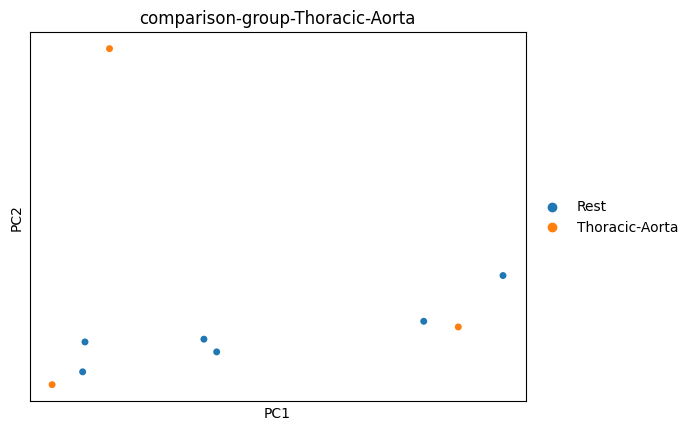

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 21.43 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.958965,-3.165684,1.366208,-2.317132,0.020497,0.99971
6330411D24Rik,18.329498,-1.007478,0.526182,-1.914695,0.055531,0.99971
A1bg,0.256220,-17.788085,371.509310,-0.047881,0.961811,0.99971
A1cf,3.614438,-0.814218,0.793357,-1.026296,0.304752,0.99971
A2m,2.202062,-1.204937,1.063074,-1.133446,0.257027,0.99971
...,...,...,...,...,...,...
hist1h2ail2,0.615788,0.237664,1.697481,0.140010,0.888652,0.99971
mrpl11,0.230146,1.389963,2.671246,0.520343,0.602825,0.99971
mrpl24,1.587699,-0.012946,1.077059,-0.012020,0.990410,0.99971


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Mesothelial_Cells_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


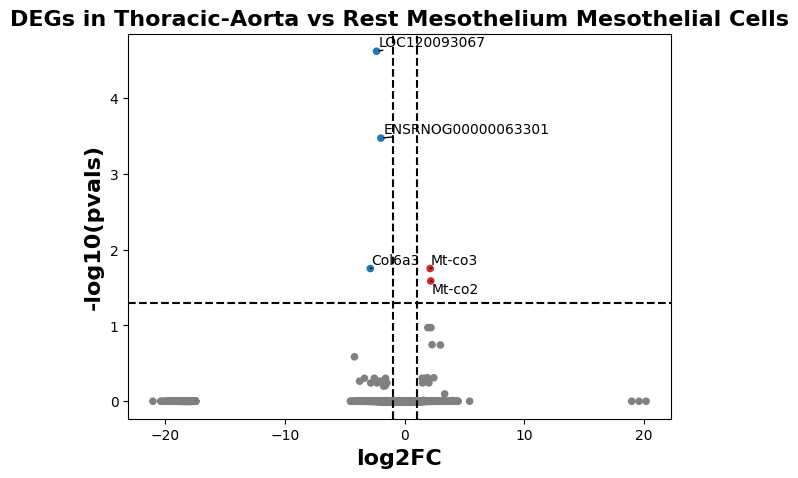

Comparing across comparison-group-Thoracic-Aorta in taPVAT Fibroblasts


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.63 seconds.

Fitting dispersion trend curve...
... done in 3.37 seconds.

Fitting MAP dispersions...
... done in 1.46 seconds.

Fitting LFCs...
... done in 1.55 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



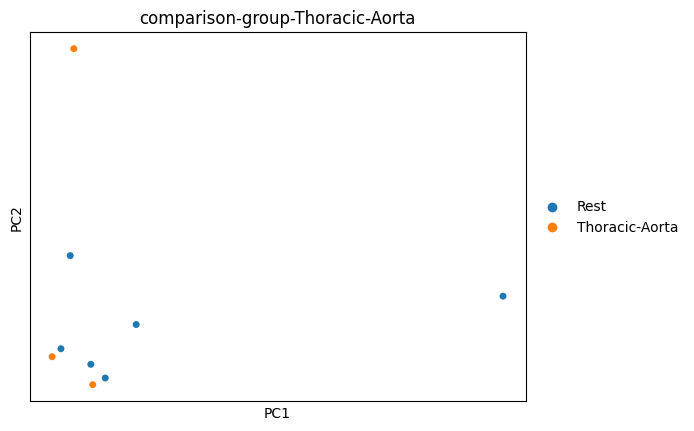

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 20.56 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.457864,-1.903619,1.792890,-1.061760,0.288345,0.999559
6330411D24Rik,17.333103,-1.412750,0.587992,-2.402668,0.016276,0.999559
A1cf,4.181524,-1.218143,0.839773,-1.450563,0.146902,0.999559
A2m,2.036559,-2.066108,1.289421,-1.602353,0.109078,0.999559
A2ml1,1.709437,-1.319925,1.213464,-1.087733,0.276713,0.999559
...,...,...,...,...,...,...
mrpl11,0.749869,-1.002740,1.727015,-0.580620,0.561496,0.999559
mrpl24,1.919095,-0.267891,1.066164,-0.251266,0.801608,0.999559
mrpl9,2.891434,0.215321,0.868501,0.247922,0.804195,0.999559


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Fibroblasts_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


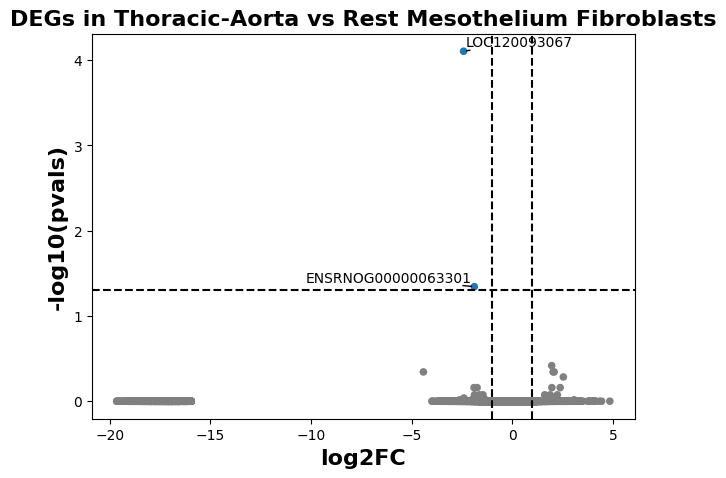

Comparing across comparison-group-Thoracic-Aorta in taPVAT Pericytes_SMCs


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.65 seconds.

Fitting dispersion trend curve...
... done in 3.33 seconds.

Fitting MAP dispersions...
... done in 1.59 seconds.

Fitting LFCs...
... done in 1.86 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



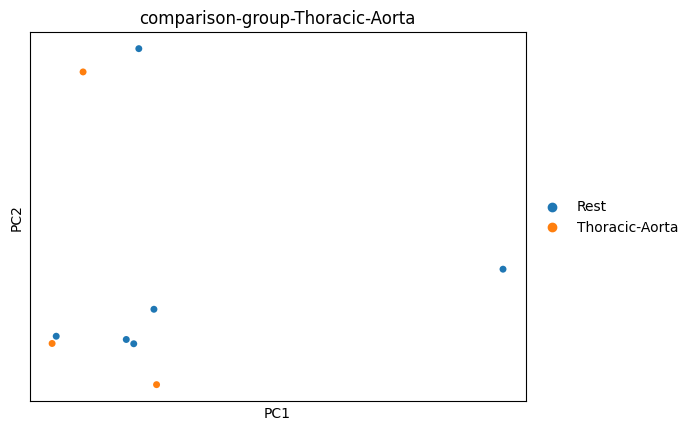

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 21.81 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,1.561672,0.413321,1.362766,0.303296,0.761664,NaN
6330411D24Rik,14.380771,-0.871413,0.493904,-1.764338,0.077675,0.231936
A1cf,5.093946,-0.598209,0.711437,-0.840846,0.400434,NaN
A2m,1.975557,-0.835255,1.045934,-0.798573,0.424538,NaN
A2ml1,1.267973,-2.674660,1.781958,-1.500967,0.133364,NaN
...,...,...,...,...,...,...
dsr-2,0.411393,2.995016,2.223707,1.346857,0.178026,NaN
mrpl11,0.238588,0.195215,2.762411,0.070668,0.943662,NaN
mrpl24,0.590564,-0.361550,1.778269,-0.203316,0.838888,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Pericytes_SMCs_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


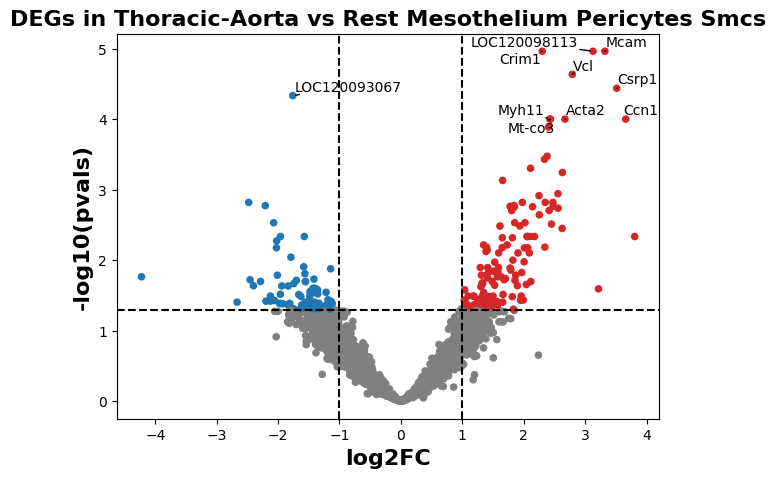

Comparing across comparison-group-Thoracic-Aorta in taPVAT Adipocytes_White


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.39 seconds.

Fitting dispersion trend curve...
... done in 2.63 seconds.

Fitting MAP dispersions...
... done in 1.36 seconds.

Fitting LFCs...
... done in 1.33 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



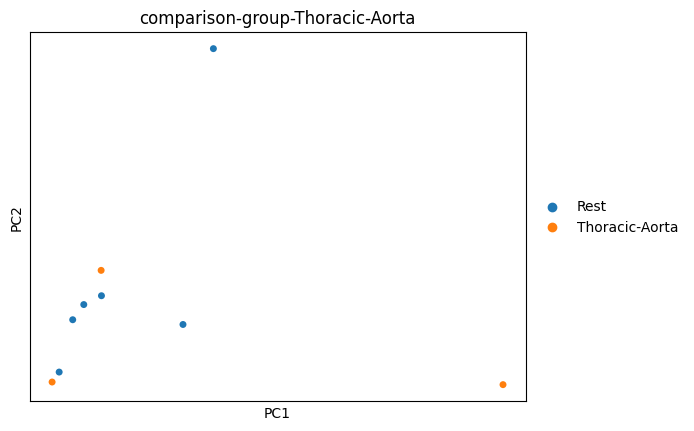

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 21.08 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
1700066B19Rik,0.195096,-1.251549,3.283501,-0.381163,0.703082,NaN
4930455H04Rik,0.447868,-2.435594,2.509306,-0.970625,0.331735,NaN
6330411D24Rik,7.938456,-1.496965,0.790001,-1.894890,0.058107,0.238871
A1cf,2.579995,-0.636941,1.011146,-0.629920,0.528747,NaN
A2m,0.924496,-1.591702,1.621860,-0.981406,0.326393,NaN
...,...,...,...,...,...,...
Zzz3,3.591668,0.903199,0.815145,1.108022,0.267852,NaN
mrpl11,0.505742,0.738547,1.959794,0.376849,0.706286,NaN
mrpl24,0.261867,-1.001332,2.725525,-0.367391,0.713328,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_White_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


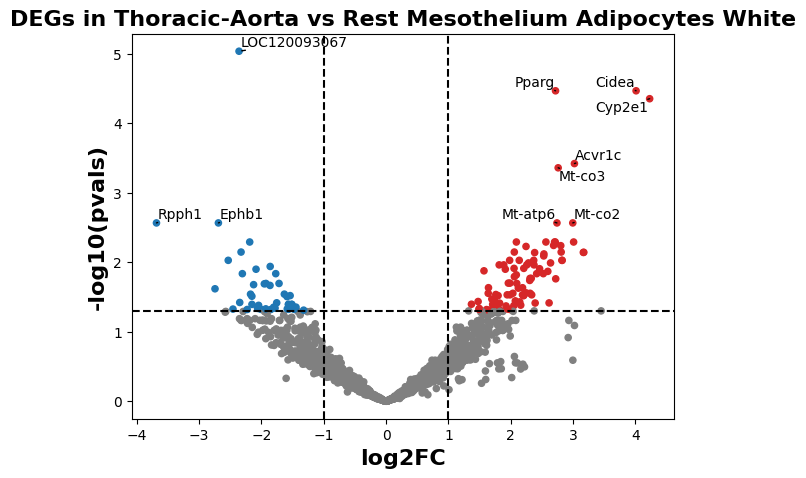

Comparing across comparison-group-Thoracic-Aorta in taPVAT Schwann_Cells


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.44 seconds.

Fitting dispersion trend curve...
... done in 2.58 seconds.

Fitting MAP dispersions...
... done in 1.10 seconds.

Fitting LFCs...
... done in 1.28 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



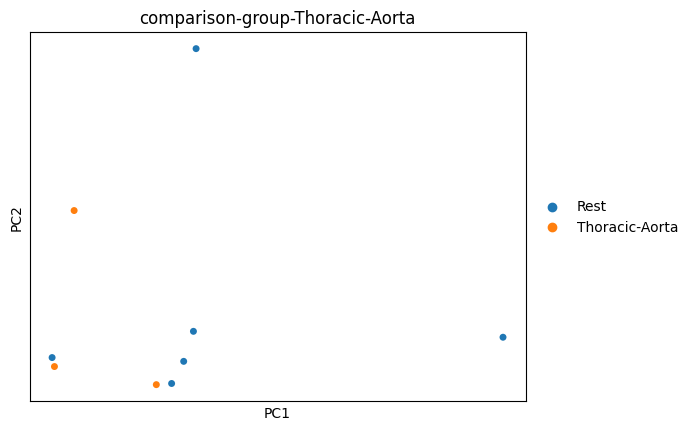

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 22.15 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.553353,0.836354,2.329418,0.359040,0.719565,NaN
6330411D24Rik,4.947484,0.158407,0.652454,0.242787,0.808171,0.977718
A1cf,1.591195,0.011057,1.141952,0.009683,0.992275,NaN
A2m,1.027405,-1.528257,1.667739,-0.916365,0.359476,NaN
A2ml1,0.479246,-17.022087,387.190477,-0.043963,0.964934,NaN
...,...,...,...,...,...,...
Zyx,2.905440,1.193800,0.839393,1.422218,0.154963,0.728402
Zzef1,3.594330,-0.091739,0.777500,-0.117992,0.906074,0.992676
Zzz3,2.472987,1.133717,0.857376,1.322311,0.186065,0.759038


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Schwann_Cells_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


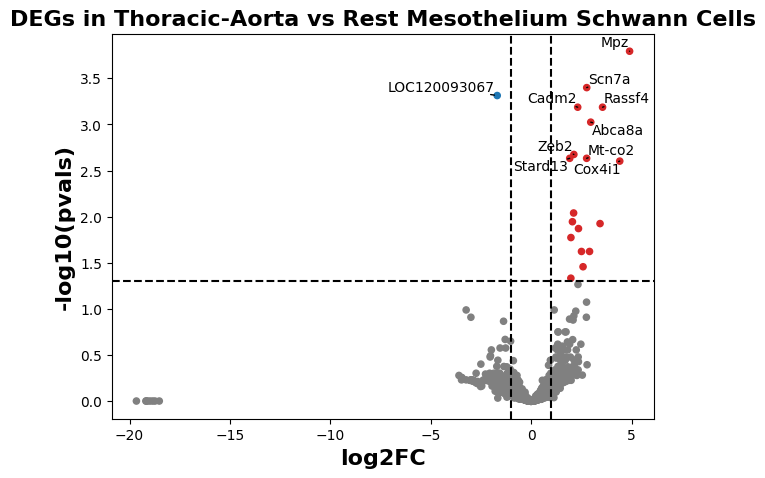

Comparing across comparison-group-Thoracic-Aorta in taPVAT Adipocytes_Brown


/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning:

Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.31 seconds.

Fitting dispersion trend curve...
... done in 2.66 seconds.

Fitting MAP dispersions...
... done in 1.30 seconds.

Fitting LFCs...
... done in 1.34 seconds.

Refitting 0 outliers.

/mnt/home/terrianl/anaconda3/envs/pydeseqEnv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



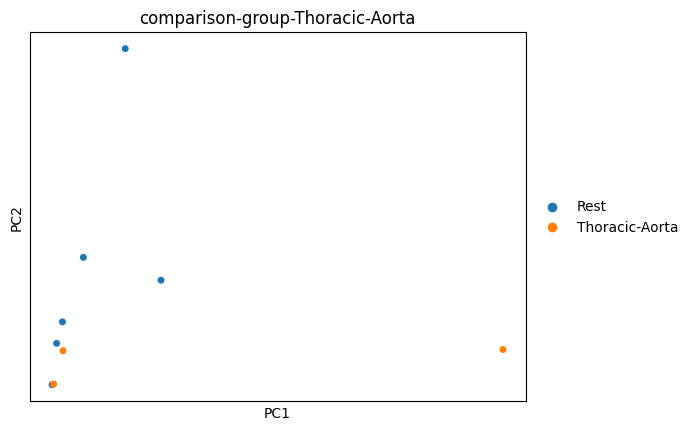

Running Wald tests...


Log2 fold change & Wald test p-value: comparison-group-Thoracic-Aorta Thoracic-Aorta vs Rest


... done in 19.73 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
4930455H04Rik,0.291871,-18.188993,372.441583,-0.048837,0.961049,NaN
6330411D24Rik,4.815761,-1.566348,0.874046,-1.792067,0.073122,0.229092
A1cf,1.178550,-3.793183,2.029391,-1.869124,0.061606,NaN
A2m,1.383717,0.129459,1.444330,0.089633,0.928579,NaN
A2ml1,1.765043,1.867120,1.314786,1.420094,0.155580,NaN
...,...,...,...,...,...,...
Zzz3,2.331144,0.890157,1.040661,0.855376,0.392343,NaN
mrpl11,0.722204,2.537915,1.730412,1.466653,0.142470,NaN
mrpl24,0.492471,1.433734,1.889415,0.758824,0.447958,NaN


/mnt/ufs18/rs-035/watts_lab/PPG_snRNAseq_Work/2025_MESO_mesPVAT_RAT_PARSE/04_Analysis/code/custom_functions_pydeseqEnv.py:365: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



files saved to: ../output/DEGs/Mesothelium_Adipocytes_Brown_Thoracic-Aorta_vs_Rest_comparison-group-Thoracic-Aorta_comparison....


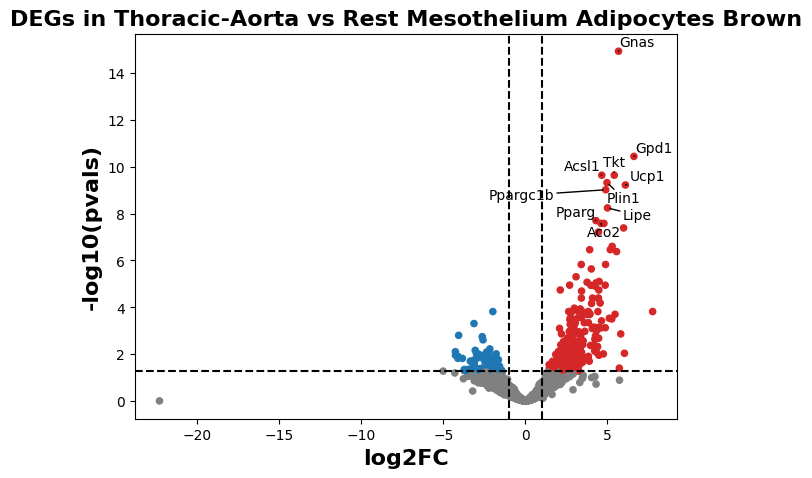

CPU times: user 7min 2s, sys: 19min 27s, total: 26min 30s
Wall time: 18min 19s


In [ ]:
%%time
### High level comparisons across cell types
deseqRes = []

group_list = ['comparison-group-Kidney', 'comparison-group-Mesentery', 'comparison-group-Thoracic-Aorta']
group1_list = ['Rest', 'Rest', 'Rest']
group2_list = ['Kidney', 'Mesentery', 'Thoracic-Aorta']

celltypes = adata.obs.celltype.unique()

for i in range(len(group_list)):
    for celltype in celltypes:
        print(f'Comparing across {group_list[i]} in taPVAT {celltype}')
              
        adata_subset = adata[adata.obs['celltype'] == celltype].copy()
        celltype = celltype
        group = group_list[i]
        group1 = group1_list[i] 
        group2 = group2_list[i]
        
        ### Get the counts of cells per sample and check if any are less than 3
        sample_counts = adata_subset.obs['sample_id'].value_counts()
        failing_samples = sample_counts[sample_counts < 3]

        ### Check if there are any failing samples before moving on to DEG analysis
        if not failing_samples.empty:
            print("There are less than 3 cells of this cell type in the following samples:")
            print(failing_samples)
            deseqRes
        else:
            ### Run DESeq and save results
            de = return_de(adata_subset, celltype, group, group1, group2)
            deseqRes.append(de)

            ### Generate and save volcano plots
            plot_volcano_df(de, celltype, group, group1, group2, return_fig = False, save = True)
            plot_volcano_df_html(de, celltype, group, group1, group2, return_fig = False, save = True)
            plt.show()
        
deseqResults2 = pd.concat(deseqRes)
deseqResults2.to_csv('../output/DEGs/Mesothelium_vs_Rest_celltype_deseq_all_genes_all.txt', sep = '\t')

## Saving all DESeq results as a single tsv file

In [10]:
deseqResults1 = pd.read_csv('../output/DEGs/Mesothelium_whole_tissue_vs_rest_deseq_.txt', sep = '\t', index_col = 0)
deseqResults2 = pd.read_csv('../output/DEGs/Mesothelium_vs_Rest_celltype_deseq_all_genes_all.txt', sep = '\t', index_col = 0)

In [11]:
deseqResults_list = [deseqResults1, deseqResults2]
deseqResults_all = pd.concat(deseqResults_list)

In [12]:
deseqResults_all

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
gene_name,,,,,,,,,,,
6330411D24Rik,101.350209,0.457426,0.398046,1.149178,0.250482,0.790749,6330411D24Rik,whole_tissue,comparison-group-Kidney,Rest,Kidney
A1cf,31.618049,0.368256,0.440103,0.836749,0.402734,0.825369,A1cf,whole_tissue,comparison-group-Kidney,Rest,Kidney
A2m,16.929886,0.796715,0.510069,1.561975,0.118294,0.749064,A2m,whole_tissue,comparison-group-Kidney,Rest,Kidney
A2ml1,15.445955,0.648653,0.533581,1.215659,0.224115,0.786551,A2ml1,whole_tissue,comparison-group-Kidney,Rest,Kidney
AABR07000398.1,281.985326,0.532859,0.373193,1.427840,0.153338,0.764235,AABR07000398.1,whole_tissue,comparison-group-Kidney,Rest,Kidney
...,...,...,...,...,...,...,...,...,...,...,...
Zrsr2,2.689943,0.667717,0.909473,0.734180,0.462839,0.650621,Zrsr2,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Zscan26,3.381086,2.055031,1.041605,1.972946,0.048502,0.187043,Zscan26,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Zswim5,3.810749,0.784481,0.768573,1.020698,0.307398,0.517941,Zswim5,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta


In [13]:
deseqResults_all.to_csv('../output/DEGs/Mesothelium_all_comparisons_vs_rest_deseq_all_genes_all.txt', sep = '\t')

In [14]:
deseq_degs_all = deseqResults_all[deseqResults_all.padj <= 0.05]

In [15]:
deseq_degs_all = deseqResults_all[(deseqResults_all.padj <= 0.05) & ((deseqResults_all.log2FoldChange >= 1)|(deseqResults_all.log2FoldChange <= -1))]\
    .sort_values('stat', ascending = False)

In [16]:
deseq_degs_all.to_csv('../output/DEGs/Mesothelium_all_comparisons_vs_rest_deseq_all_degs_pvalue_0.05.txt', sep = '\t')

In [17]:
top_genes = deseq_degs_all[deseq_degs_all['log2FoldChange'] >= 1]
bottom_genes = deseq_degs_all[deseq_degs_all['log2FoldChange'] <= -1]

In [18]:
top_genes.to_csv('../output/DEGs/Mesothelium_all_comparisons_vs_rest_deseq_all_degs_pvalue_0.05_top.txt', sep = '\t')
bottom_genes.to_csv('../output/DEGs/Mesothelium_all_comparisons_vs_rest_deseq_all_degs_pvalue_0.05_bottom.txt', sep = '\t')

In [20]:
bottom_genes

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
gene_name,,,,,,,,,,,
Dnah7,4.955543,-2.535868,0.893149,-2.839243,4.522070e-03,4.975558e-02,Dnah7,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Mybpc1,6.015385,-3.001208,1.055120,-2.844422,4.449201e-03,4.937342e-02,Mybpc1,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Hs3st5,6.136322,-2.327796,0.818294,-2.844693,4.445418e-03,4.937342e-02,Hs3st5,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Megf10,2.926737,-3.638148,1.278265,-2.846161,4.424980e-03,4.937342e-02,Megf10,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
Atp10b,6.193372,-2.247660,0.789327,-2.847567,4.405483e-03,4.937342e-02,Atp10b,Adipocytes_Brown,comparison-group-Thoracic-Aorta,Rest,Thoracic-Aorta
...,...,...,...,...,...,...,...,...,...,...,...
Pi16,42.020201,-3.808281,0.614565,-6.196713,5.765461e-10,1.384864e-06,Pi16,Fibroblasts,comparison-group-Mesentary,Rest,Mesentary
Hba-a1,97.285066,-2.501501,0.398761,-6.273176,3.537570e-10,5.123917e-07,Hba-a1,whole_tissue,comparison-group-Mesentary,Rest,Mesentary
Pi16,95.592404,-2.824409,0.411920,-6.856686,7.047654e-12,2.381872e-08,Pi16,whole_tissue,comparison-group-Mesentary,Rest,Mesentary
